# Task 1/2 — Exploratory Data Analysis: Brent Oil Prices

Daily Brent crude oil prices, 20-May-1987 to 30-Sep-2022. This notebook covers:

1. Loading and cleaning the data
2. Trend analysis of the raw price series
3. Log returns and stationarity testing
4. Volatility clustering
5. Overlaying researched events on the price series
6. Discussion of how these properties inform the change point modeling approach (Task 2)

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Make the repo root importable so `src/` modules can be used from the notebook.
sys.path.insert(0, str(Path('..').resolve()))

from src.data import load_price_data, load_events
from src.preprocessing import clip_date_range, add_log_returns, add_rolling_volatility
from src.stationarity import adf_test, format_adf_result
from src.plotting import plot_price_series, plot_log_returns, plot_rolling_volatility, plot_price_with_events

plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', None)

## 1. Load and clean data

In [2]:
df = load_price_data('../data/raw/BrentOilPrices.csv')

# The brief scopes this analysis through 30-Sep-2022; the raw file runs a few
# weeks past that (to 14-Nov-2022), so we clip to the documented end date.
df = clip_date_range(df, '2022-09-30')

print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Missing values: {df['Price'].isna().sum()}")
print(f"Duplicate dates: {df.index.duplicated().sum()}")
df.head()

Shape: (8980, 1)
Date range: 1987-05-20 to 2022-09-30
Missing values: 0
Duplicate dates: 0


,Price
Date,
1987-05-20,18.63
1987-05-21,18.45
1987-05-22,18.55
1987-05-25,18.60
1987-05-26,18.63


In [3]:
df['Price'].describe()

count    8980.000000
mean       48.262774
std        32.806012
min         9.100000
25%        19.030000
50%        38.330000
75%        69.782500
max       143.950000
Name: Price, dtype: float64

## 2. Raw price series: trend and visible shocks

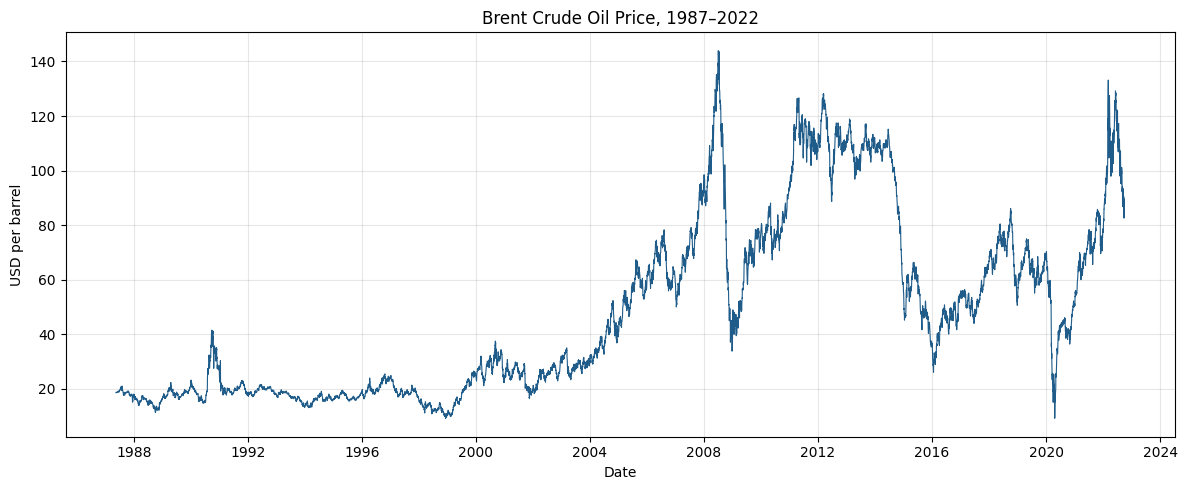

In [4]:
plot_price_series(
    df,
    title='Brent Crude Oil Price, 1987–2022',
    save_path='../data/processed/price_series.png',
)
plt.show()

**Observations:**
- The series shows a strong long-run upward drift from the ~$15–20 range in the late 1980s/1990s to a peak near $147 in mid-2008, followed by a sharp collapse during the Global Financial Crisis.
- Several distinct regimes are visible: a long, relatively stable/low-price period through the 1990s; a sustained rally 2003–2008; the 2008 crash and 2009–2014 recovery/plateau near $100–115; the 2014–2016 collapse; a 2016–2019 partial recovery; the COVID-19 crash in 2020; and the 2021–2022 rally following the Russia–Ukraine war.
- The raw series is clearly **non-stationary** — it trends over multi-year horizons and its variance is not constant across regimes (compare the calm 1990s to the turbulent 2008/2020 windows). This visually motivates working with returns rather than levels for the change point model.

## 3. Log returns and stationarity

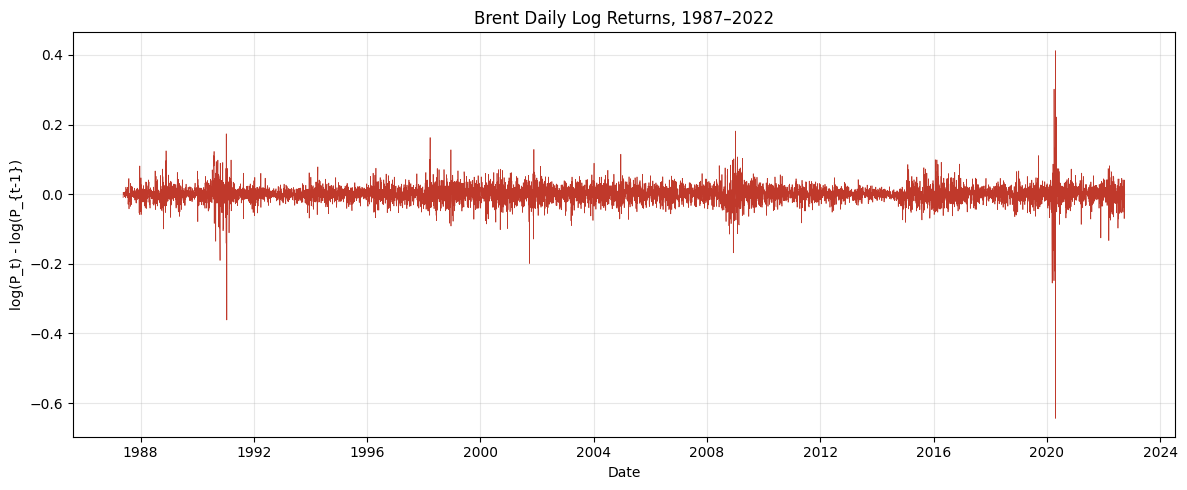

In [5]:
df = add_log_returns(df)

plot_log_returns(
    df,
    title='Brent Daily Log Returns, 1987–2022',
    save_path='../data/processed/log_returns.png',
)
plt.show()

**Volatility clustering:** notice how large swings (e.g. 2008–2009, 2014–2016, 2020) bunch together in time — periods of turbulence are followed by more turbulence, and calm periods by more calm. This is classic volatility clustering, and it means a model assuming a single constant variance for the whole series (or even for a whole "regime") is a simplification; in practice both the mean **and** the variance shift together at many of these boundaries.

In [6]:
price_result = adf_test(df['Price'], label='Raw price level')
return_result = adf_test(df['log_return'], label='Log returns')

print(format_adf_result(price_result))
print()
print(format_adf_result(return_result))

--- ADF test: Raw price level ---
ADF statistic: -2.0496
p-value:       0.2653
critical value (1%): -3.4311
critical value (5%): -2.8619
critical value (10%): -2.5669
=> Series appears non-stationary at the chosen significance level

--- ADF test: Log returns ---
ADF statistic: -16.3888
p-value:       2.706e-29
critical value (1%): -3.4311
critical value (5%): -2.8619
critical value (10%): -2.5669
=> Series appears stationary at the chosen significance level


**Interpretation:** the Augmented Dickey-Fuller test is expected to fail to reject the unit-root null for the raw price level (confirming non-stationarity — the series wanders without reverting to a fixed mean) but to strongly reject it for log returns (confirming returns are stationary in the mean). This is the standard justification for modeling **returns**, not price levels, with models that assume a fixed mean/variance within a regime (such as the Bayesian switch-point model in Task 2).

## 4. Rolling volatility

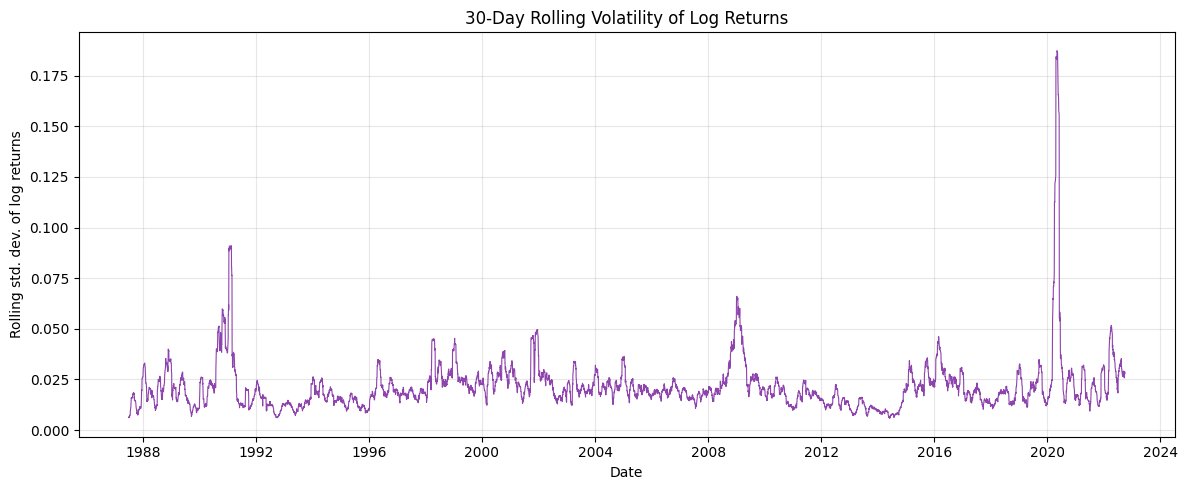

In [7]:
window = 30
df = add_rolling_volatility(df, column='log_return', window=window)

plot_rolling_volatility(df, window=window, save_path='../data/processed/rolling_volatility.png')
plt.show()

Volatility spikes sharply around 2008–2009, 2014–2016, 2020, and 2022 — each coinciding with a major event in `data/events.csv` (Global Financial Crisis, OPEC's 2014 non-cut decision, the COVID-19 demand shock / Saudi-Russia price war, and Russia's invasion of Ukraine, respectively). This is a first, purely descriptive piece of evidence linking the researched event list to observable shifts in the data — to be formalized with the Bayesian change point model in Task 2.

## 5. Price series with researched events overlaid

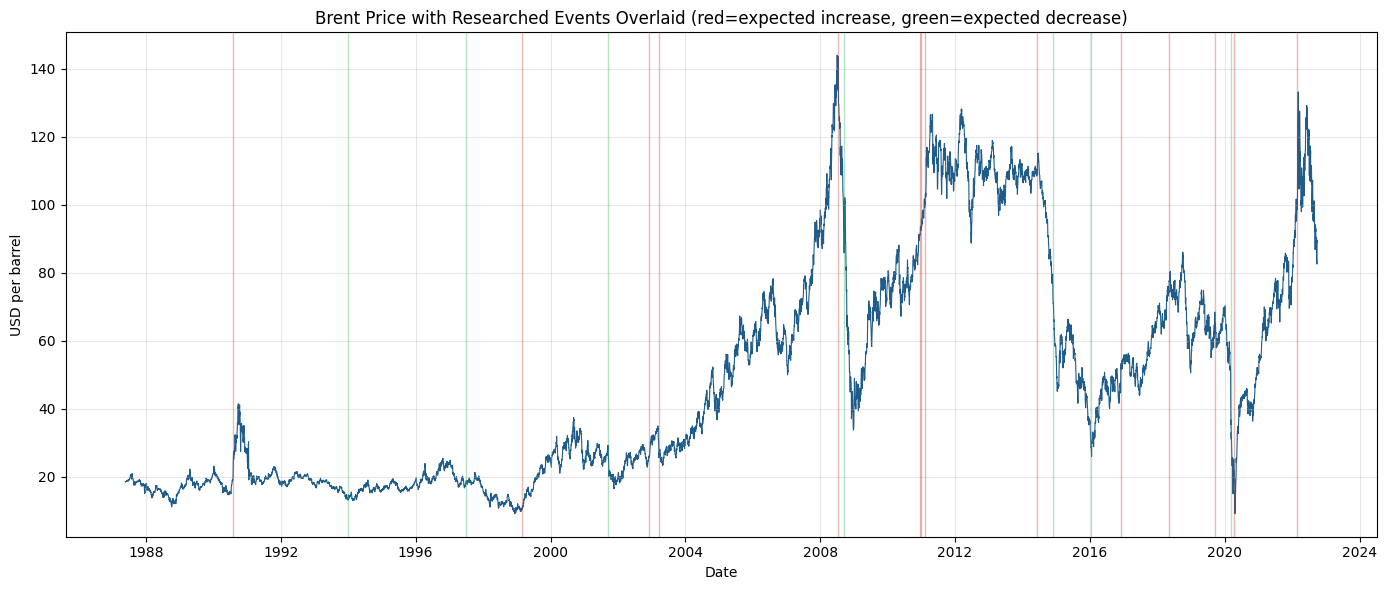

In [8]:
events = load_events('../data/events.csv')

plot_price_with_events(df, events, save_path='../data/processed/price_with_events.png')
plt.show()

## 6. Summary: how these properties inform modeling choices

- **Trend & non-stationarity of levels** → use log returns (or explicitly model a trend/segment-wise level) rather than raw prices in the change point model, since the switch-point model assumes a fixed mean within each regime.
- **Volatility clustering** → a single global variance is unrealistic; consider allowing `sigma` to also switch at `tau` (not just `mu`), or fitting the model over shorter windows around candidate events rather than the full 35-year history.
- **Multiple visible regimes** → a single-`tau` model will only recover the single most dominant shift in whatever window it is given; capturing the full history requires either analyzing sub-periods around each candidate event or extending to a multiple-change-point framework (noted in Future Work).
- **Descriptive event alignment** (rolling volatility spikes lining up with `data/events.csv` dates) motivates, but does not prove, the causal hypotheses to be tested formally in Task 2 — see `docs/assumptions_and_limitations.md` for the correlation-vs-causation discussion.